# Model Training (coupler_NCap_cap_matrix)
## Capacitance --> Qiskit Metal

Instead of training the inverse model to directly predict Qiskit Metal parameters and comparing
against ground truth SQuADDs params, we now chain the inverse model with a frozen surrogate (Qiskit-->Capacitance)
and train on the reconstruction error in capacitance space. This works better because multiple
different Qiskit param sets can produce the same capacitance matrix, and before we werent letting the inverse model explore different parameter sets. By measuring error in capacitance instead, this makes the model only care about if the predicted params give the right desired capacitance values, not whether they match perfectly the exact qiskit data set.

## Configuration

In [3]:
# The parameter file is where the hyperparameters are set. 
# It's reccomended to look at that file first, its interesting and you can set stuff there

from parameters_surrogate_defined_loss import *

## Library

In [4]:
import os, gc, joblib, json, time, sys, math, csv

# Disable some console warnings so you can be free of them printing. 
# Comment the next two lines if you are a professional and/or like looking at warnings.
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf, platform
tf.keras.backend.set_floatx("float32")

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Input, Dense, Dropout, LeakyReLU
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.python.client import device_lib
from keras_tuner import HyperModel, RandomSearch
from keras_tuner import BayesianOptimization

from pathlib import Path
import numpy as np
import pandas as pd
from pandas import json_normalize
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import clear_output
from mpl_toolkits.mplot3d import Axes3D

In [5]:
seed = 0

# Input seed value. If this value is the same, the random number generator 
# will generate the same set of random values every time. We like reproducibility:)
np.random.seed(seed)

# Set the seed value for reproducibility in tensorflow too, cuz consistency
tf.random.set_seed(seed)

## Check GPU

In [6]:
# Look at what you are working with. If you dont have a nice GPU I highly reccomend finding one
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 4513101339288550478
xla_global_id: -1
, name: "/device:XLA_CPU:0"
device_type: "XLA_CPU"
memory_limit: 17179869184
locality {
}
incarnation: 14006695454553201406
physical_device_desc: "device: XLA_CPU device"
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 39419510784
locality {
  bus_id: 1
  links {
  }
}
incarnation: 4741093114220437627
physical_device_desc: "device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:00:10.0, compute capability: 8.0"
xla_global_id: 416903419
, name: "/device:XLA_GPU:0"
device_type: "XLA_GPU"
memory_limit: 17179869184
locality {
}
incarnation: 8669681018909459316
physical_device_desc: "device: XLA_GPU device"
xla_global_id: -1
]


I0000 00:00:1772118398.801735 1080348 gpu_device.cc:2020] Created device /device:GPU:0 with 37593 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:00:10.0, compute capability: 8.0


In [7]:
# make sure something prints in the list. if it doesnt, run:
# import sys
# !{sys.executable} -m pip install -U pip
# !{sys.executable} -m pip install -U "tensorflow[and-cuda]"
# in this cell and restart the kernel.

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
# check cuda
!{sys.executable} -m pip list | egrep "tensorflow|nvidia-(cuda|cudnn|cublas|nccl)"

nvidia-cublas-cu11        11.11.3.6
nvidia-cublas-cu12        12.9.1.4
nvidia-cuda-cupti-cu11    11.8.87
nvidia-cuda-cupti-cu12    12.9.79
nvidia-cuda-nvcc-cu12     12.9.86
nvidia-cuda-nvrtc-cu11    11.8.89
nvidia-cuda-nvrtc-cu12    12.9.86
nvidia-cuda-runtime-cu11  11.8.89
nvidia-cuda-runtime-cu12  12.9.79
nvidia-cudnn-cu11         9.1.0.70
nvidia-cudnn-cu12         9.17.1.4
nvidia-nccl-cu11          2.21.5
nvidia-nccl-cu12          2.29.2
tensorflow                2.20.0
tensorflow-datasets       4.8.3+nightly
tensorflow-estimator      2.11.0
tensorflow-metadata       1.13.1


## Dataset

### Load

In [9]:
#Load the one-hot encoded data (saved from ml_00 notebook)

# inputs are the capacitance values (what we want to invert)
X_train = np.load(f'{DATA_DIR}/npy/x_train_one_hot_encoding_scaled.npy', allow_pickle=True)
X_val   = np.load(f'{DATA_DIR}/npy/x_val_one_hot_encoding_scaled.npy', allow_pickle=True)
X_test  = np.load(f'{DATA_DIR}/npy/x_test_one_hot_encoding_scaled.npy', allow_pickle=True)

# Qiskit Metal params in one-hot encoding
y_train = np.load(f'{DATA_DIR}/npy/y_train_one_hot_encoding_scaled.npy', allow_pickle=True)
y_val   = np.load(f'{DATA_DIR}/npy/y_val_one_hot_encoding_scaled.npy', allow_pickle=True)
y_test  = np.load(f'{DATA_DIR}/npy/y_test_one_hot_encoding_scaled.npy', allow_pickle=True)

# column names
with open('X_names', 'r') as f:
    cap_column_names = f.read().splitlines()

oh_col_names   = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()
cont_col_names = np.load('y_columns_continuous.npy', allow_pickle=True).astype(str).tolist()
fc_oh_col_names = np.load('y_columns_fingers.npy', allow_pickle=True).astype(str).tolist()

n_continuous = len(cont_col_names)
n_fc_onehot  = len(fc_oh_col_names)
n_oh_total   = n_continuous + n_fc_onehot

print(f'Inputs (Capacitance):     {X_train.shape[1]} columns')
print(f'Outputs (one-hot Qiskit): {y_train.shape[1]} columns ({n_continuous} continuous + {n_fc_onehot} finger_count one-hot)')
print(f'\nCapacitance columns:  {cap_column_names}')
print(f'Continuous Qiskit columns: {cont_col_names}')
print(f'Finger count one-hot columns: {fc_oh_col_names}')

Inputs (Capacitance):     6 columns
Outputs (one-hot Qiskit): 13 columns (3 continuous + 10 finger_count one-hot)

Capacitance columns:  ['top_to_top', 'top_to_bottom', 'top_to_ground', 'bottom_to_bottom', 'bottom_to_ground', 'ground_to_ground']
Continuous Qiskit columns: ['design_options.cap_gap', 'design_options.cap_width', 'design_options.finger_length']
Finger count one-hot columns: ['design_options.finger_count_1', 'design_options.finger_count_2', 'design_options.finger_count_3', 'design_options.finger_count_4', 'design_options.finger_count_5', 'design_options.finger_count_6', 'design_options.finger_count_7', 'design_options.finger_count_8', 'design_options.finger_count_9', 'design_options.finger_count_10']


In [10]:
X_train = X_train.astype('float32')
y_train = y_train.astype('float32')
X_val   = X_val.astype('float32')
y_val   = y_val.astype('float32')

### Visualize

In [11]:
#look at the shapes of training and test sets
print('X_train.shape: ', X_train.shape)
print('X_val.shape:   ', X_val.shape)
print('X_test.shape:  ', X_test.shape)
print('y_train.shape: ', y_train.shape)
print('y_val.shape:   ', y_val.shape)
print('y_test.shape:  ', y_test.shape)
print('\ny_train[0]: ', y_train[0])

X_train.shape:  (301, 6)
X_val.shape:    (64, 6)
X_test.shape:   (65, 6)
y_train.shape:  (301, 13)
y_val.shape:    (64, 13)
y_test.shape:   (65, 13)

y_train[0]:  [0.  0.8 0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0. ]


In [12]:
display(X_train)
display(y_train)

array([[0.25080466, 0.20990732, 0.3306395 , 0.30081633, 0.36219245,
        0.36319846],
       [0.40300596, 0.33585343, 0.5219632 , 0.4487671 , 0.5251337 ,
        0.53231275],
       [0.09505053, 0.01220755, 0.26467332, 0.02343084, 0.03163965,
        0.09262483],
       ...,
       [0.46411738, 0.37217692, 0.6188697 , 0.5535152 , 0.6749636 ,
        0.6631028 ],
       [0.1971561 , 0.19512492, 0.20978302, 0.19535603, 0.19367942,
        0.19768766],
       [0.3910667 , 0.43209445, 0.30815578, 0.38361895, 0.3479543 ,
        0.34186673]], dtype=float32)

array([[0.        , 0.8       , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [1.        , 0.8       , 0.6666667 , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.6       , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [1.        , 0.8       , 0.33333334, ..., 1.        , 0.        ,
        0.        ],
       [1.        , 0.        , 0.6666667 , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.2       , 0.6666667 , ..., 1.        , 0.        ,
        0.        ]], dtype=float32)

In [13]:

# Look at how it was split and decide if we like the split (we do for now)
total = len(X_train) + len(X_test) + len(X_val)
print('---------------------------------------')  
print('Train set shape x:      {}, {:.2f}%'.format(len(X_train), (len(X_train)*100.)/total))
print('Validation set shape x: {}, {:.2f}%'.format(len(X_val), (len(X_val)*100.)/total))
print('Test set shape x:       {}, {:.2f}%'.format(len(X_test), (len(X_test)*100.)/total))
print('---------------------------------------')

total = len(y_train) + len(y_test) + len(y_val)
print('---------------------------------------')  
print('Train set shape y:      {}, {:.2f}%'.format(len(y_train), (len(y_train)*100.)/total))
print('Validation set shape y: {}, {:.2f}%'.format(len(y_val), (len(y_val)*100.)/total))
print('Test set shape y:       {}, {:.2f}%'.format(len(y_test), (len(y_test)*100.)/total))
print('---------------------------------------')

---------------------------------------
Train set shape x:      301, 70.00%
Validation set shape x: 64, 14.88%
Test set shape x:       65, 15.12%
---------------------------------------
---------------------------------------
Train set shape y:      301, 70.00%
Validation set shape y: 64, 14.88%
Test set shape y:       65, 15.12%
---------------------------------------


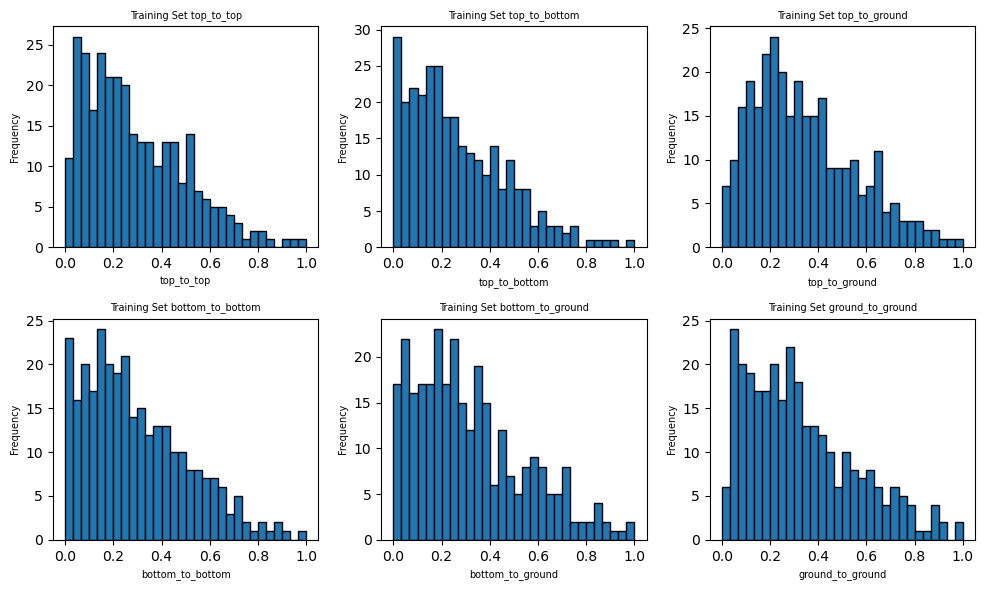

In [14]:
# Bin the input data (capacitance values) and look at distribution

num_cols = X_train.shape[1]
num_rows = math.ceil(num_cols / 3)

fig, axes = plt.subplots(num_rows, 3, figsize=(10, 3 * num_rows))
axes = axes.ravel()

for i in range(num_cols):
    axes[i].hist(X_train[:, i], bins=30, edgecolor='black')
    label = cap_column_names[i] if i < len(cap_column_names) else f'col_{i}'
    axes[i].set_title(f'Training Set {label}', fontsize=7)
    axes[i].set_xlabel(label, fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/surrogate_loss_training_set_input_distribution.pdf')
plt.show()

In [15]:
steps_per_epoch = int(np.ceil(len(X_train) / TRAIN_BATCH_SIZE))
LR_DECAY_STEPS = steps_per_epoch * 20   # decay every ~20 epochs

## MLP

### Create model

Reccomended to download a third party app like "Sleep control Center" or "Amphetamine" to prevent computer from sleeping during the many hour/day long training process

### Make conversion layer

This will take us from one-hot encoded values to the linear version that the surrogate models need. its a custom layer that will not have updatable weights or anything that will mess up training (hopefully)

In [16]:
# Extract finger count values from col names (like 'design_options.finger_count_2' goes to just 2)
fc_values = sorted([int(c.split('_')[-1]) for c in fc_oh_col_names])
print(f'Finger count values: {fc_values}')

Finger count values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [17]:
# Determine the linear encoding column order by reading the original data
# (The surrogate expects columns in the original dataframe order with finger_count as one column)
columns_to_drop = ['design_tool','design_options.prime_width',
    'design_options.prime_gap', 'design_options.second_width',
    'design_options.second_gap', 'design_options.cap_gap_ground',
    'design_options.cap_distance', 'design_options.orientation',
    'design_tool', 'coupler_type']

df_tmp = pd.read_json('coupler-NCap-cap_matrix.json')
y_tmp = json_normalize(df_tmp['design']).drop(columns=columns_to_drop)
linear_col_names = list(y_tmp.columns)
del df_tmp, y_tmp

fc_linear_idx = linear_col_names.index('design_options.finger_count')
n_linear_cols = len(linear_col_names)
print(f'Linear column order ({n_linear_cols} cols): {linear_col_names}')
print(f'finger_count is at position {fc_linear_idx} in the linear order')

Linear column order (4 cols): ['design_options.cap_gap', 'design_options.cap_width', 'design_options.finger_length', 'design_options.finger_count']
finger_count is at position 3 in the linear order


In [18]:
# Load the finger_count scaler from the surrogate's linear encoding
fc_scaler = joblib.load('scalers/scaler_y_linear_design_options.finger_count.save')
fc_data_min   = float(fc_scaler.data_min_[0])
fc_data_range = float(fc_scaler.data_range_[0])
print(f'finger_count linear scaler: min={fc_data_min}, range={fc_data_range}')

finger_count linear scaler: min=1.0, range=9.0


The scalers are different for the version of the data that was used in this notebook vs what the surrogate model expects. We have to take that into account and transform from one to the other in this layer we are building:

In [19]:
cont_scale_a = np.ones(n_continuous, dtype=np.float32)
cont_scale_b = np.zeros(n_continuous, dtype=np.float32)

for i, col in enumerate(cont_col_names):
    oh_sc  = joblib.load(f'scalers/scaler_y_one_hot_{col}.save') # load the scaler for one hot encoding
    lin_sc = joblib.load(f'scalers/scaler_y_linear_{col}.save') #load scaler used in linear encoding for the surrogate model
    oh_min,  oh_range  = float(oh_sc.data_min_[0]),  float(oh_sc.data_range_[0]) 
    lin_min, lin_range = float(lin_sc.data_min_[0]), float(lin_sc.data_range_[0])
    if lin_range > 0:
        #save the slope and intercept for this column to use later when going from one hot scaler to linear scaler later
        cont_scale_a[i] = oh_range / lin_range
        cont_scale_b[i] = (oh_min - lin_min) / lin_range

In [20]:
# Check if scalers are identical (they should be since same training data)
if np.allclose(cont_scale_a, 1.0) and np.allclose(cont_scale_b, 0.0):
    print('Continuous column scalers are identical between one-hot and linear (as expected)')
else:
    print('WARNING: continuous column scalers differ between one-hot and linear!')
    print(f'  scale_a range: [{cont_scale_a.min():.6f}, {cont_scale_a.max():.6f}]')
    print(f'  scale_b range: [{cont_scale_b.min():.6f}, {cont_scale_b.max():.6f}]')

Continuous column scalers are identical between one-hot and linear (as expected)


In [21]:
# Load and freeze the surrogate model so its not updated during training
SURROGATE_PATH = 'model/best_keras_model_model2_surrogate.keras'
surrogate = load_model(SURROGATE_PATH, compile=False)

#freeze it
surrogate.trainable = False
for layer in surrogate.layers:
    layer.trainable = False

surr_input_dim = surrogate.input_shape[-1]
assert surr_input_dim == n_linear_cols, (
    f'Surrogate expects {surr_input_dim} inputs but linear encoding has {n_linear_cols} columns'
)
print(f'\nSurrogate loaded & frozen: {SURROGATE_PATH} ({surrogate.count_params():,} params, 0 trainable)')
print(f'Surrogate input dim: {surr_input_dim}  (matches linear encoding: {n_linear_cols})')

I0000 00:00:1772118400.644654 1080348 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 37593 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:00:10.0, compute capability: 8.0



Surrogate loaded & frozen: model/best_keras_model_model2_surrogate.keras (8,806 params, 0 trainable)
Surrogate input dim: 4  (matches linear encoding: 4)


In [22]:
# Build the custom layer to go from one hot encoded outputs to linear inputs for the surrogate model
# Its made of fixed affine transforms and a weighted sum.
# Gradients flow through it because everything is differentiable.

class OneHotToLinearLayer(tf.keras.layers.Layer):
    def __init__(self, n_continuous, fc_values, fc_data_min, fc_data_range,
             fc_linear_idx, cont_scale_a, cont_scale_b, **kwargs):
        kwargs.setdefault('trainable', False)  # default to False, but don't override if already set
        super().__init__(**kwargs)
        self._n_cont    = n_continuous
        self._fc_vals   = tf.constant([fc_values], dtype=tf.float32)    # (1, n_fc)
        self._fc_min    = tf.constant(fc_data_min, dtype=tf.float32)
        self._fc_range  = tf.constant(fc_data_range, dtype=tf.float32)
        self._fc_idx    = fc_linear_idx
        self._scale_a   = tf.constant(cont_scale_a, dtype=tf.float32)   # (n_cont,)
        self._scale_b   = tf.constant(cont_scale_b, dtype=tf.float32)   # (n_cont,)
        # store raw values for get_config
        self._cfg = dict(n_continuous=n_continuous, fc_values=fc_values,
                         fc_data_min=fc_data_min, fc_data_range=fc_data_range,
                         fc_linear_idx=fc_linear_idx,
                         cont_scale_a=list(cont_scale_a),
                         cont_scale_b=list(cont_scale_b))

    def call(self, inputs):
        # Split: [continuous_cols | one_hot_finger_count_cols]
        continuous = inputs[:, :self._n_cont]
        fc_onehot  = inputs[:, self._n_cont:]
        
        # Cast constants to match input dtype (mixed precision sends float16)
        fc_vals  = tf.cast(self._fc_vals, inputs.dtype)
        fc_min   = tf.cast(self._fc_min, inputs.dtype)
        fc_range = tf.cast(self._fc_range, inputs.dtype)
        scale_a  = tf.cast(self._scale_a, inputs.dtype)
        scale_b  = tf.cast(self._scale_b, inputs.dtype)
        
        # Convert one-hot to single finger_count value via weighted sum
        fc_raw = tf.reduce_sum(fc_onehot * fc_vals, axis=1, keepdims=True)
        
        # Scale to match the surrogate's linear encoding scaler
        fc_scaled = (fc_raw - fc_min) / fc_range
        
        # Rescale continuous columns from one-hot scaler space to linear scaler space
        cont_rescaled = continuous * scale_a + scale_b
        
        # Insert finger_count at the correct position in linear column order
        return tf.concat([
            cont_rescaled[:, :self._fc_idx],
            fc_scaled,
            cont_rescaled[:, self._fc_idx:]
        ], axis=1)

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config

# Build the conversion layer instance
oh_to_linear = OneHotToLinearLayer(
    n_continuous=n_continuous,
    fc_values=fc_values,
    fc_data_min=fc_data_min,
    fc_data_range=fc_data_range,
    fc_linear_idx=fc_linear_idx,
    cont_scale_a=cont_scale_a,
    cont_scale_b=cont_scale_b,
    name='oh_to_linear'
)

# Quick sanity test
test_input = tf.constant(y_train[:3].astype('float32'))
test_output = oh_to_linear(test_input)
print(f'Conversion test: input shape {test_input.shape} → output shape {test_output.shape}')
print(f'Expected output shape: (3, {n_linear_cols})')

Conversion test: input shape (3, 13) → output shape (3, 4)
Expected output shape: (3, 4)


### Create Model by Hand

In [23]:
# just checkin to make sure everything looks good still, we want float32
print(X_train.dtype, X_train.shape)
print(y_train.dtype, y_train.shape)

print("TF:", tf.__version__)
print("OS:", platform.platform())
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Built with ROCm:", tf.test.is_built_with_rocm())
print("GPUs:", tf.config.list_physical_devices("GPU"))

float32 (301, 6)
float32 (301, 13)
TF: 2.20.0
OS: Linux-6.3.12-200.fc38.x86_64-x86_64-with-glibc2.34
Built with CUDA: True
Built with ROCm: False
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [24]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    # Model shape string for file naming
    model_shape = f'surrogate_loss_mlp_{X_train.shape[1]}_'
    model_shape += '_'.join(str(l) for l in NEURONS_PER_LAYER)
    model_shape += f'_{y_train.shape[1]}'

In [25]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    # Build inverse model that takes capacitance --> one-hot encoded Qiskit Metal params
    inverse_model = Sequential(name='inverse_model')
    inverse_model.add(Input(shape=(X_train.shape[1],), name='cap_input'))
    
    for i, n in enumerate(NEURONS_PER_LAYER):
        inverse_model.add(Dense(n, name='fc{}'.format(i),
                        kernel_initializer='lecun_uniform',
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
        inverse_model.add(LeakyReLU(negative_slope=0.01, name='leaky_relu{}'.format(i)))
        inverse_model.add(Dropout(rate=TRAIN_DROPOUT_RATE, name='dropout{}'.format(i)))
    
    # output layer predicts all one-hot encoded Qiskit params
    inverse_model.add(Dense(y_train.shape[1], activation='linear', name='qiskit_output_oh',
                    kernel_initializer='lecun_uniform'))
    
    # this does capacitance-->inverse model--> Qiskit params-->convert_to_linear-->surrogate(frozen)-->Cap_reconstructed
    combined_input = Input(shape=(X_train.shape[1],), name='combined_input')
    predicted_qiskit_oh = inverse_model(combined_input)
    predicted_qiskit_linear = oh_to_linear(predicted_qiskit_oh)  # differentiable conversion
    reconstructed_cap = surrogate(predicted_qiskit_linear)
    model = Model(combined_input, reconstructed_cap, name='combined_model')
    
    print('Inverse model (outputs one-hot encoded Qiskit params):')
    inverse_model.summary()
    print('\nCombined model (inverse + conversion + frozen surrogate):')
    model.summary()

In [26]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=LR_INITIAL,  
        decay_steps=LR_DECAY_STEPS,        
        decay_rate=LR_DECAY_RATE,          
        staircase=LR_STAIRCASE             
    )
    
    # loss is on reconstructed capacitance vs original input capacitance
    model.compile(
        optimizer=tf.optimizers.Adam(learning_rate=lr_schedule),  
        loss=TRAIN_LOSS,                                         
        metrics=[TRAIN_LOSS]                                     
    )

In [27]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    !mkdir -p model
    best_model_file = 'model/{}_best_model.keras'.format(model_shape)
    last_model_file = 'model/{}_last_model.keras'.format(model_shape)

Enable training (`train_and_save`) to overwrite the model file.

In [28]:
train_and_save = True

We use Adam optimizer, minimize the loss specified in parameters, and early stop.

#### Training

In [29]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    class TrainingPlot(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs={}):
            self.losses = []
            self.val_losses = []
            self.logs = []
        
        def on_epoch_end(self, epoch, logs={}):
            self.logs.append(logs)
            self.losses.append(logs.get('loss'))
            self.val_losses.append(logs.get('val_loss'))
            
            if len(self.losses) > 1:
                clear_output(wait=True)
                N = np.arange(0, len(self.losses))
                plt.figure()
                plt.plot(N, self.losses, label='train_loss')
                plt.plot(N, self.val_losses, label='val_loss')
                plt.title('Training Loss [Epoch {}]'.format(epoch))
                plt.xlabel('Epoch #')
                plt.ylabel('Loss')
                plt.legend()
                plt.show()


class LearningRateMonitor(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.learning_rates = []

    def _current_lr(self, optimizer):
        lr = getattr(optimizer, 'lr', None) or getattr(optimizer, 'learning_rate', None)
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            return float(lr(optimizer.iterations).numpy())
        return float(tf.keras.backend.get_value(lr))

    def on_epoch_end(self, epoch, logs=None):
        try:
            lr_val = self._current_lr(self.model.optimizer)
        except Exception:
            lr_val = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.learning_rates.append(lr_val)

In [30]:
%%time

# Train the model — target is the input capacitance (reconstruction through frozen surrogate)
history = None  
if not KERAS_TUNER and not SWEEP_PARAM_NUM and not SWEEP_DATA_AMOUNT:
    if train_and_save: 
        early_stopping = EarlyStopping(
            monitor='val_loss',
            mode='min',
            patience=TRAIN_EARLY_STOPPING_PATIENCE,
            verbose=1
        )
    
        plot_callback = TrainingPlot()
        lr_monitor = LearningRateMonitor()
        
        model_checkpoint = ModelCheckpoint(
            filepath=best_model_file,          
            monitor='val_loss',
            mode='min',
            save_best_only=True,
            verbose=0
        )

        history = model.fit(
            np.asarray(X_train),    # input: capacitance
            np.asarray(X_train),    # target: SAME capacitance (reconstruction loss)
            epochs=400,                   
            batch_size=TRAIN_BATCH_SIZE,  
            validation_data=(np.asarray(X_val), np.asarray(X_val)),  
            callbacks=[early_stopping, model_checkpoint, plot_callback, lr_monitor],  
            verbose=1
        )
        
        model.save(last_model_file)

CPU times: user 12 μs, sys: 2 μs, total: 14 μs
Wall time: 26.2 μs


Load the saved best model and use it from now on.

In [31]:
if not KERAS_TUNER and not SWEEP_PARAM_NUM and not SWEEP_DATA_AMOUNT:
    model = load_model(best_model_file, custom_objects={
        'OneHotToLinearLayer': OneHotToLinearLayer
    })

### Sweep total number of parameters to find the right range

In [32]:
if SWEEP_PARAM_NUM:
    qiskit_oh_dim = y_train.shape[1]
    cap_dim = X_train.shape[1]
    
    def build_combined_mlp(neurons_per_layer):
        inv = Sequential(name='inverse_model')
        inv.add(Input(shape=(cap_dim,), name='cap_input'))
        for i, n in enumerate(neurons_per_layer):
            inv.add(Dense(n, name=f'fc{i}', kernel_initializer='lecun_uniform',
                            kernel_regularizer=tf.keras.regularizers.l2(1e-4)))
            inv.add(LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}'))
            inv.add(Dropout(rate=TRAIN_DROPOUT_RATE, name=f'dropout{i}'))
        inv.add(Dense(qiskit_oh_dim, activation='linear', name='qiskit_output_oh',
                        kernel_initializer='lecun_uniform'))
        combined_input = Input(shape=(cap_dim,))
        qiskit_oh = inv(combined_input)
        qiskit_lin = oh_to_linear(qiskit_oh)
        cap_recon = surrogate(qiskit_lin)
        return Model(combined_input, cap_recon)
    
    def make_optimizer():
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=LR_INITIAL,
            decay_steps=LR_DECAY_STEPS,
            decay_rate=LR_DECAY_RATE,
            staircase=LR_STAIRCASE
        )
        return tf.optimizers.Adam(learning_rate=lr_schedule)
    
    def train_one_config(neurons_per_layer, seed=0):
        tf.keras.backend.clear_session()
        tf.random.set_seed(seed)
        np.random.seed(seed)
        # reload surrogate + rebuild conversion layer after clear_session
        global surrogate, oh_to_linear
        surrogate = load_model(SURROGATE_PATH, compile=False)
        surrogate.trainable = False
        for layer in surrogate.layers:
            layer.trainable = False
        oh_to_linear = OneHotToLinearLayer(
            n_continuous=n_continuous, fc_values=fc_values,
            fc_data_min=fc_data_min, fc_data_range=fc_data_range,
            fc_linear_idx=fc_linear_idx, cont_scale_a=cont_scale_a,
            cont_scale_b=cont_scale_b, name='oh_to_linear')
        combined = build_combined_mlp(neurons_per_layer)
        combined.compile(optimizer=make_optimizer(), loss=TRAIN_LOSS, metrics=[TRAIN_LOSS])
        early_stopping = EarlyStopping(
            monitor='val_loss', mode='min',
            patience=TRAIN_EARLY_STOPPING_PATIENCE, verbose=0,
            restore_best_weights=True)
        history = combined.fit(
            np.asarray(X_train), np.asarray(X_train),
            validation_data=(np.asarray(X_val), np.asarray(X_val)),
            epochs=400, batch_size=TRAIN_BATCH_SIZE,
            callbacks=[early_stopping], verbose=0)
        best_val = min(history.history['val_loss'])
        return combined, history, best_val

In [33]:
if SWEEP_PARAM_NUM:
    from datetime import datetime
    run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
    out_dir = 'sweep_outputs'
    os.makedirs(out_dir, exist_ok=True)
    csv_path = os.path.join(out_dir, f'surrogate_loss_sweep_results_{run_id}.csv')
    df.to_csv(csv_path, index=False)
    print('Saved:', csv_path)

In [34]:
if SWEEP_PARAM_NUM:
    plt.figure()
    plt.scatter(df['total_params'], df['best_val_loss'])
    plt.xscale('log')
    plt.xlabel('Total parameters (log scale)')
    plt.ylabel('Best val_loss')
    plt.title('Surrogate Loss: Best val_loss vs model size')
    plt.savefig('plots/surrogate_loss_params_vs_loss.png')
    plt.show()

### Sweep amount of data used in training

In [35]:
if SWEEP_DATA_AMOUNT:
    FIXED_DEPTH = 1          
    FIXED_WIDTH = 1024        
    FIXED_NEURONS = [FIXED_WIDTH] * FIXED_DEPTH
    TRAIN_FRACTIONS = np.linspace(0.3, 1, 20)  
    SWEEP_SEEDS = [0, 1, 2, 3, 4]  

    def make_subset(X, y, frac, seed):
        assert 0 < frac <= 1.0
        n = len(X)
        m = max(1, int(np.floor(frac * n)))
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=m, replace=False)
        return X[idx], y[idx], m

### Keras Tuner to Find Best Hyperparameters

Run this if you want to use keras tuner to make the model rather than doing it by hand

In [36]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Input, Dropout
    from tensorflow.keras.regularizers import l2
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    from keras_tuner import HyperModel, RandomSearch
    from tensorflow.keras.models import load_model, Model

In [37]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    cap_dim = X_train.shape[1]
    qiskit_oh_dim = y_train.shape[1]
    
    def build_hypermodel(hp):
        tf.keras.backend.clear_session()
        gc.collect()
        
        # reload surrogate + rebuild conversion layer after clear_session
        surr = load_model(SURROGATE_PATH, compile=False)
        surr.trainable = False
        for layer in surr.layers:
            layer.trainable = False
        converter = OneHotToLinearLayer(
            n_continuous=n_continuous, fc_values=fc_values,
            fc_data_min=fc_data_min, fc_data_range=fc_data_range,
            fc_linear_idx=fc_linear_idx, cont_scale_a=cont_scale_a,
            cont_scale_b=cont_scale_b, name='oh_to_linear')
        
        n_layers = hp.Int('n_layers', min_value=1, max_value=4, default=2)
        neurons_per_layer = [hp.Int(f'neurons_{i}', min_value=64, max_value=1024, step=64) for i in range(n_layers)]
        dropout_rate = hp.Float('dropout_rate', 0.0, 0.3, step=0.05)
        l2_reg = hp.Float('l2_reg', 1e-6, 1e-2, sampling='LOG', default=1e-4)
        lr_initial = hp.Float('learning_rate', 1e-3, 1e-1, sampling='LOG', default=1e-2)
        use_batchnorm = hp.Boolean('use_batchnorm', default=True)
        
        # build the inverse model (outputs one-hot encoded Qiskit params)
        inv = Sequential(name='inverse_model')
        inv.add(Input(shape=(cap_dim,), name='cap_input'))
        for i, n_units in enumerate(neurons_per_layer):
            inv.add(Dense(n_units, name=f'fc{i}', kernel_initializer='he_normal',
                            kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
            if use_batchnorm:
                inv.add(tf.keras.layers.BatchNormalization(name=f'bn{i}'))
            inv.add(LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}'))
            inv.add(Dropout(rate=dropout_rate, name=f'dropout{i}'))
        inv.add(Dense(qiskit_oh_dim, name='qiskit_output_oh', kernel_initializer='he_normal'))
        
        # this does capacitance-->inverse model--> Qiskit params-->convert_to_linear-->surrogate(frozen)-->Cap_reconstructed
        combined_input = Input(shape=(cap_dim,), name='combined_input')
        qiskit_oh = inv(combined_input)
        qiskit_lin = converter(qiskit_oh)
        cap_recon = surr(qiskit_lin)
        combined = Model(combined_input, cap_recon, name='combined_model')
        combined.compile(optimizer=tf.optimizers.Adam(learning_rate=lr_initial),
                      loss=TRAIN_LOSS, metrics=[TRAIN_LOSS])
        return combined

In [38]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    tuner = BayesianOptimization(
        build_hypermodel,
        objective='val_loss',
        max_trials=KERAS_TUNER_TRIALS,
        executions_per_trial=2,
        directory=KERAS_DIR + '/hyper_tuning_surrogate_defined_loss',
        project_name='surrogate_loss_mlp_tuning_bayesian',
    )

Reloading Tuner from keras/hyper_tuning_surrogate_defined_loss/surrogate_loss_mlp_tuning_bayesian/tuner0.json


In [39]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    early_stopping = EarlyStopping(
        monitor='val_loss', mode='min',
        patience=TRAIN_EARLY_STOPPING_PATIENCE, verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=max(10, TRAIN_EARLY_STOPPING_PATIENCE // 3),
        min_lr=1e-6, verbose=1
    )

In [40]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    tuner.search(
        np.asarray(X_train), np.asarray(X_train),    # target is the reconstructed input
        epochs=400, batch_size=TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(X_val), np.asarray(X_val)),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

Trial 303 Complete [00h 02m 00s]
val_loss: 0.01344540435820818

Best val_loss So Far: 0.006529330043122172
Total elapsed time: 16h 29m 59s


In [41]:
encoding = 'surrogate_defined_loss'
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    os.makedirs('model', exist_ok=True)
    best_model_file = f'model/best_keras_model_{encoding}.keras'
    best_combined = tuner.get_best_models(1)[0]
    best_combined.save(best_model_file)
    
    # also save just the inverse model by itself for later use
    inverse_only = best_combined.get_layer('inverse_model')
    inverse_only.save(f'model/best_inverse_model_{encoding}.keras')
    print(f'Saved combined model: {best_model_file}')
    print(f'Saved inverse-only model: model/best_inverse_model_{encoding}.keras')
    
    tf.keras.backend.clear_session()
    gc.collect()
    with tf.device('/CPU:0'):
        loaded_model = load_model(best_model_file, compile=False,
                                  custom_objects={'OneHotToLinearLayer': OneHotToLinearLayer})

/home/olivias/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saved combined model: model/best_keras_model_surrogate_defined_loss.keras
Saved inverse-only model: model/best_inverse_model_surrogate_defined_loss.keras


### View the model

In [42]:
if KERAS_TUNER and not SWEEP_PARAM_NUM:
    print('Combined model (inverse + conversion + frozen surrogate):')
    best_combined.summary()
    print('\nInverse model only:')
    inverse_only.summary()

if not KERAS_TUNER and not SWEEP_PARAM_NUM:
    print('\n---- Model Summary ----')
    model.summary()

Combined model (inverse + conversion + frozen surrogate):


Model: "combined_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ combined_input (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inverse_model (Sequential)      │ (None, 13)             │        71,565 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oh_to_linear                    │ (None, 4)              │             0 │
│ (OneHotToLinearLayer)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 6)              │         8,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,371 (313.95 KB)

 Trainable params: 71,565 (279.55 KB)

...

Model: "inverse_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu1 (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu2 (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu3 (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qiskit_output_oh (Dense)        │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,565 (279.55 KB)

 Trainable params: 71,565 (279.55 KB)

 Non-trainable params: 0 (0.00 B)

### Evaluation

Plot training history.

### Visualize gradients for best model

In [44]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and VISUALIZE_GRADIENTS:
    class GradientNormLogger(tf.keras.callbacks.Callback):
        def __init__(self, x_probe, y_probe, layer_name_prefixes=('fc', 'output'),
                     log_every=1, max_items_per_prefix=10, verbose=1):
            super().__init__()
            self.x_probe = tf.convert_to_tensor(x_probe)
            self.y_probe = tf.convert_to_tensor(y_probe)
            self.layer_name_prefixes = tuple(layer_name_prefixes)
            self.log_every = int(log_every)
            self.max_items_per_prefix = int(max_items_per_prefix)
            self.verbose = int(verbose)
            self.records = []
        def _want_layer(self, var_name):
            return any(var_name.startswith(pfx) for pfx in self.layer_name_prefixes)
        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            if (epoch + 1) % self.log_every != 0: return
            with tf.GradientTape() as tape:
                y_pred = self.model(self.x_probe, training=True)
                loss = self.model.compiled_loss(self.y_probe, y_pred)
            grads = tape.gradient(loss, self.model.trainable_weights)
            rec = {'epoch': int(epoch + 1), 'probe_loss': float(loss.numpy())}
            per_layer = {}
            for w, g in zip(self.model.trainable_weights, grads):
                if g is None: continue
                wname = w.name.split(':')[0]
                if not self._want_layer(wname): continue
                g_norm = tf.linalg.global_norm([g]).numpy().item()
                rec[f'grad_norm__{wname}'] = float(g_norm)
                layer_key = wname.split('/')[0]
                per_layer.setdefault(layer_key, []).append(g_norm)
            for layer_key, norms in per_layer.items():
                rec[f'grad_mean__{layer_key}'] = float(np.mean(norms))
                rec[f'grad_max__{layer_key}'] = float(np.max(norms))
            g_all = [g for g in grads if g is not None]
            rec['grad_global_norm'] = float(tf.linalg.global_norm(g_all).numpy().item()) if g_all else float('nan')
            self.records.append(rec)
            for k in list(rec.keys()):
                if k != 'epoch': logs[k] = rec[k]
        def to_csv(self, path):
            import csv
            if not self.records: return
            keys = sorted({k for r in self.records for k in r.keys()})
            with open(path, 'w', newline='') as f:
                w = csv.DictWriter(f, fieldnames=keys); w.writeheader(); w.writerows(self.records)

In [45]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and VISUALIZE_GRADIENTS:
    probe_n = min(256, len(X_train))
    x_probe = np.asarray(X_train[:probe_n])
    y_probe = np.asarray(X_train[:probe_n])  # target = input (reconstruction)
    grad_logger = GradientNormLogger(x_probe=x_probe, y_probe=y_probe,
        layer_name_prefixes=('fc0', 'qiskit_output_oh'), log_every=1, verbose=1)
    best_hp = tuner.get_best_hyperparameters(1)[0]
    model = tuner.hypermodel.build(best_hp)
    lr_monitor = LearningRateMonitor()
    history = model.fit(
        np.asarray(X_train), np.asarray(X_train),
        epochs=400, batch_size=TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(X_val), np.asarray(X_val)),
        callbacks=[early_stopping, lr_monitor, grad_logger], verbose=1)
    grad_logger.to_csv(f'plots/{encoding}_gradients.csv')
    del model; tf.keras.backend.clear_session(); gc.collect()

In [46]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and VISUALIZE_GRADIENTS:
    dfg = pd.DataFrame(grad_logger.records)
    plt.figure()
    plt.plot(dfg['epoch'], dfg['grad_global_norm'])
    plt.yscale('log')
    plt.title('Gradient tracking for a single batch across epochs')
    plt.xlabel('Epoch'); plt.ylabel('Gradient magnitude (log scale)')
    plt.tight_layout(); plt.savefig(f'plots/{encoding}_grad_global_norm.pdf'); plt.show()
    for lk in ['fc0', 'qiskit_output_oh']:
        col = f'grad_mean__{lk}'
        if col in dfg.columns:
            plt.figure(); plt.plot(dfg['epoch'], dfg[col]); plt.yscale('log')
            plt.title(f'Gradient Mean Norm: {lk} (probe batch)')
            plt.xlabel('Epoch'); plt.ylabel('Mean grad norm (log scale)')
            plt.tight_layout(); plt.savefig(f'plots/{encoding}_grad_mean_{lk}.pdf'); plt.show()

### Look at best model

Epoch 1/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - loss: 0.8496 - mae: 0.8481 - val_loss: 0.5068 - val_mae: 0.5054
Epoch 2/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.4660 - mae: 0.4646 - val_loss: 0.2825 - val_mae: 0.2811
Epoch 3/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2248 - mae: 0.2233 - val_loss: 0.0916 - val_mae: 0.0902
Epoch 4/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0971 - mae: 0.0957 - val_loss: 0.0789 - val_mae: 0.0775
Epoch 5/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0688 - mae: 0.0674 - val_loss: 0.0542 - val_mae: 0.0528
Epoch 6/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0546 - mae: 0.0532 - val_loss: 0.0548 - val_mae: 0.0534
Epoch 7/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0506 - mae: 0.0492 - val_loss: 0.0514 - val_mae: 0.0500
Epoch 8/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0465 - mae: 0.0451 - val_loss: 0.0465 - val_mae: 0.0451
Epoch 9/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0425 - mae: 0

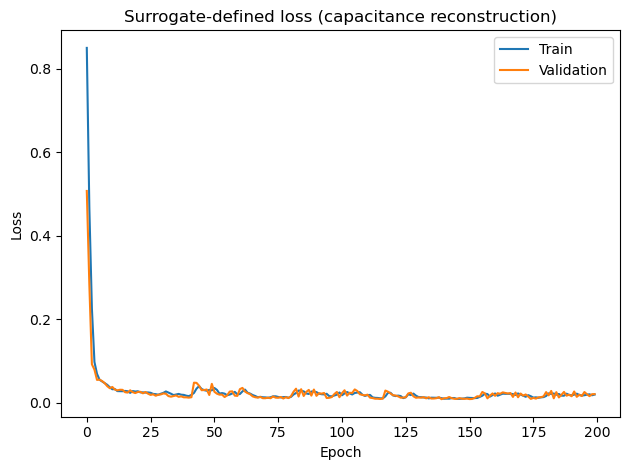

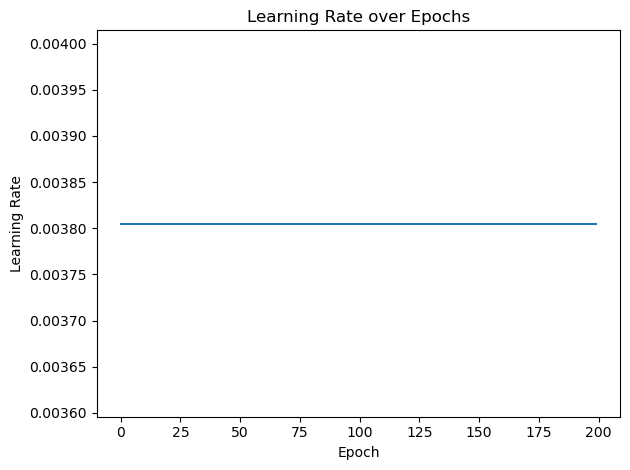

In [47]:
if KERAS_TUNER and not SWEEP_PARAM_NUM and not VISUALIZE_GRADIENTS:
    best_hp = tuner.get_best_hyperparameters(1)[0]
    model = tuner.hypermodel.build(best_hp)
    lr_monitor = LearningRateMonitor()
    history = model.fit(
        np.asarray(X_train), np.asarray(X_train),
        epochs=400, batch_size=TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(X_val), np.asarray(X_val)),
        callbacks=[early_stopping, lr_monitor], verbose=1)
    del model; tf.keras.backend.clear_session(); gc.collect()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Surrogate-defined loss (capacitance reconstruction)')
plt.ylabel('Loss'); plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='best')
plt.tight_layout(); plt.savefig(f'plots/surrogate_loss_history.pdf'); plt.show()

plt.plot(lr_monitor.learning_rates)
plt.title('Learning Rate over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Learning Rate')
plt.tight_layout(); plt.savefig(f'plots/surrogate_loss_learning_rate.pdf'); plt.show()

### Test set evaluation

In [48]:
# Evaluate on test set
tf.keras.backend.clear_session()
gc.collect()

def get_loss(eval_out):
    if isinstance(eval_out, dict):
        return float(eval_out.get('loss', list(eval_out.values())[0]))
    if isinstance(eval_out, (list, tuple, np.ndarray)):
        return float(eval_out[0])
    return float(eval_out)

combined_model = load_model(best_model_file, compile=False,
    custom_objects={'OneHotToLinearLayer': OneHotToLinearLayer})
combined_model.compile(optimizer='adam', loss=TRAIN_LOSS)
reconstruction_loss = get_loss(combined_model.evaluate(np.asarray(X_test), np.asarray(X_test)))
reconstruction_loss = get_loss(reconstruction_loss)

print(f'Reconstruction test loss ({TRAIN_LOSS}): {reconstruction_loss}')

# also evaluate how well the inverse model predicts Qiskit params directly
inverse_model = combined_model.get_layer('inverse_model')
qiskit_oh_pred = inverse_model.predict(np.asarray(X_test), verbose=0)
qiskit_mse = float(np.mean((np.asarray(y_test) - qiskit_oh_pred) ** 2))
print(f'Qiskit param MSE in one-hot space (for reference): {qiskit_mse}')

results_df = pd.DataFrame([{
    'Model': 'Inverse (Surrogate-Defined Loss)',
    'Train Loss Metric': TRAIN_LOSS,
    'Reconstruction Loss': reconstruction_loss,
    'Qiskit Param MSE (OH)': qiskit_mse,
}])
print(results_df.to_string(index=False))
results_df.to_csv('surrogate_loss_test_results.csv', index=False)
test_loss_result = reconstruction_loss

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 244ms/step - loss: 0.0079
Reconstruction test loss (mae): 0.00789081584662199
Qiskit param MSE in one-hot space (for reference): 0.17115765541002792
                           Model Train Loss Metric  Reconstruction Loss  Qiskit Param MSE (OH)
Inverse (Surrogate-Defined Loss)               mae             0.007891               0.171158


## Compare predictions vs. test set

In [49]:
csv_data = [[
    DATA_AUGMENTATION,
    'surrogate_loss_model',
    'InverseModel_SurrogateLoss',
    test_loss_result,
    TRAIN_LOSS,
    TRAIN_DROPOUT_RATE,
    TRAIN_EARLY_STOPPING_PATIENCE,
    TRAIN_BATCH_SIZE,
    '0.15/0.15',
    LR_INITIAL,
    LR_DECAY_STEPS,
    LR_DECAY_RATE,
    LR_STAIRCASE
]]

csv_file = 'surrogate_loss_history_losses.csv'
if not os.path.exists(csv_file):
    with open(csv_file, 'w') as file:
        file.write('data_augmentation,model_shape,model_type,test_loss,train_loss,train_dropout_rate,'
                   'train_early_stop_patience,train_batch_size,train_val_split,lr_initial,'
                   'lr_decay_step,lr_decay_rate,lr_stair_case\n')
with open(csv_file, mode='a', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(csv_data)
df = pd.read_csv(csv_file)
styled_df = df.style.apply(lambda s: ['color: red' if v else '' for v in s], subset=['test_loss'])
display(styled_df)

,data_augmentation,model_shape,model_type,test_loss,train_loss,train_dropout_rate,train_early_stop_patience,train_batch_size,train_val_split,lr_initial,lr_decay_step,lr_decay_rate,lr_stair_case
0,True,surrogate_loss_model,InverseModel_SurrogateLoss,0.016601,mae,0.060000,60,90,0.15/0.15,0.000929,80,0.990000,False
1,True,surrogate_loss_model,InverseModel_SurrogateLoss,0.016601,mae,0.060000,60,90,0.15/0.15,0.000929,80,0.990000,False
2,True,surrogate_loss_model,InverseModel_SurrogateLoss,0.007891,mae,0.060000,60,90,0.15/0.15,0.000929,80,0.990000,False


In [50]:
# predictaroo on test set
tf.keras.backend.clear_session()
gc.collect()

with tf.device('/CPU:0'):
    combined_model = load_model(best_model_file, compile=False,
        custom_objects={'OneHotToLinearLayer': OneHotToLinearLayer})
    inverse_model = combined_model.get_layer('inverse_model')
    cap_reconstructed = combined_model.predict(np.asarray(X_test), verbose=0)
    qiskit_oh_predicted = inverse_model.predict(np.asarray(X_test), verbose=0)

In [51]:
# look at how well the reconstructed capacitance matches the input capacitance

X_test_cur = np.asarray(X_test)
y_test_cur = np.asarray(y_test)  # ground truth Qiskit params in one-hot (for reference)
cap_recon  = np.asarray(cap_reconstructed)
qiskit_pred = np.asarray(qiskit_oh_predicted)

n_samples, n_cap_cols = X_test_cur.shape
n_oh_cols = qiskit_pred.shape[1]
n_samples_to_show = 3

# reconstruction errors (capacitance space — this is what we trained on)
cap_abs_errors = np.abs(X_test_cur - cap_recon)

print('########## Capacitance Reconstruction (what the loss is based on) #############')
for i in range(n_samples_to_show):
    rows = []
    for j in range(n_cap_cols):
        label = cap_column_names[j] if j < len(cap_column_names) else f'cap_col_{j}'
        rows.append({'param': label, 'ref': X_test_cur[i,j], 'pred': cap_recon[i,j],
                     'abs_error': cap_abs_errors[i,j]})
    print(f'— Sample {i} — Capacitance reconstruction')
    print(pd.DataFrame(rows).to_string(index=False))
    print()
print('Cap reconstruction error stats (scaled):')
print('  min:', float(cap_abs_errors.min()), ' median:', float(np.median(cap_abs_errors)),
      ' max:', float(cap_abs_errors.max()))

########## Capacitance Reconstruction (what the loss is based on) #############
— Sample 0 — Capacitance reconstruction
           param      ref     pred  abs_error
      top_to_top 0.008322 0.008198   0.000124
   top_to_bottom 0.005650 0.006644   0.000994
   top_to_ground 0.036568 0.034066   0.002501
bottom_to_bottom 0.006921 0.006968   0.000048
bottom_to_ground 0.008502 0.011564   0.003063
ground_to_ground 0.011026 0.010308   0.000718

— Sample 1 — Capacitance reconstruction
           param      ref     pred  abs_error
      top_to_top 0.091476 0.092450   0.000974
   top_to_bottom 0.064207 0.065597   0.001389
   top_to_ground 0.158028 0.146396   0.011632
bottom_to_bottom 0.111460 0.111247   0.000213
bottom_to_ground 0.142611 0.144975   0.002364
ground_to_ground 0.146250 0.146390   0.000140

— Sample 2 — Capacitance reconstruction
           param      ref     pred  abs_error
      top_to_top 0.402785 0.408255   0.005470
   top_to_bottom 0.367666 0.365447   0.002219
   top_to_ground

### Unscaled test vs predictions

In [52]:
# Unscale everything and look at errors in real units that we can actually make sense of
with open('X_names', 'r') as f:
    cap_names = f.read().splitlines()
qiskit_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()
# Unscale input capacitance using X scalers
# (check which scaler prefix is available)
x_scaler_prefix = 'scaler_X_one_hot' if os.path.exists(f'scalers/scaler_X_one_hot_{cap_names[0]}.save') else 'scaler_X_linear'
X_test_unscaled = np.asarray(X_test_cur.copy())
for i in range(X_test_unscaled.shape[0]):
    for j in range(X_test_unscaled.shape[1]):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{cap_name}.save')
        X_test_unscaled[i, j] = scaler.inverse_transform([[X_test_unscaled[i, j]]])[0][0]
# Unscale reconstructed capacitance using same X scalers
cap_recon_unscaled = np.asarray(cap_recon.copy())
for i in range(cap_recon_unscaled.shape[0]):
    for j in range(cap_recon_unscaled.shape[1]):
        cap_name = cap_names[j] if j < len(cap_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{cap_name}.save')
        cap_recon_unscaled[i, j] = scaler.inverse_transform([[cap_recon_unscaled[i, j]]])[0][0]
# Unscale Qiskit param predictions (one-hot encoded)
qiskit_pred_unscaled = np.asarray(qiskit_pred.copy())
y_test_unscaled = np.asarray(y_test_cur.copy())
for i in range(qiskit_pred_unscaled.shape[0]):
    for j in range(qiskit_pred_unscaled.shape[1]):
        col_name = qiskit_names[j] if j < len(qiskit_names) else f'col_{j}'
        # one-hot finger_count columns are already 0/1, no scaler to invert
        if col_name.startswith('design_options.finger_count_'):
            continue
        scaler = joblib.load(f'scalers/scaler_y_one_hot_{col_name}.save')
        qiskit_pred_unscaled[i, j] = scaler.inverse_transform([[qiskit_pred_unscaled[i, j]]])[0][0]
        y_test_unscaled[i, j] = scaler.inverse_transform([[y_test_unscaled[i, j]]])[0][0]
n_samples_to_show = 3
cap_abs_unscaled = np.abs(X_test_unscaled - cap_recon_unscaled)

print('########## Unscaled Capacitance Reconstruction (what the loss is based on) #############')
for i in range(n_samples_to_show):
    # Capacitance reconstruction table
    rows = []
    for j in range(X_test_unscaled.shape[1]):
        rows.append({'param': cap_names[j], 'ref_unscaled': X_test_unscaled[i,j],
                     'pred_unscaled': cap_recon_unscaled[i,j], 'abs_error': cap_abs_unscaled[i,j]})
    print(f'— Sample {i} (Unscaled) — Capacitance reconstruction')
    print(pd.DataFrame(rows).to_string(index=False))

    # Predicted Qiskit params that produced this capacitance
    print(f'\n ------ Predicted Qiskit Metal params for sample {i}: -------')
    for j, col_name in enumerate(qiskit_names):
        if col_name.startswith('design_options.finger_count_'):
            continue  # skip individual one-hot columns, we'll decode them below
        pred_val = qiskit_pred_unscaled[i, j]
        ref_val  = y_test_unscaled[i, j]
        short_name = col_name.replace('design_options.', '')
        print(f'    {short_name:30s}  pred={pred_val}  ref={ref_val}  err={abs(pred_val - ref_val):}')

    # Decode one-hot finger_count → single predicted value
    fc_cols = [c for c in qiskit_names if c.startswith('design_options.finger_count_')]
    fc_indices = [qiskit_names.index(c) for c in fc_cols]
    fc_pred_oh = qiskit_pred_unscaled[i, fc_indices]
    fc_ref_oh  = y_test_unscaled[i, fc_indices]
    predicted_fc = fc_values[np.argmax(fc_pred_oh)]
    true_fc      = fc_values[np.argmax(fc_ref_oh)]
    print(f'    {"finger_count":30s}  pred={predicted_fc}  ref={true_fc}')
    print()

print('Unscaled cap reconstruction error stats:')
print('  min:', float(cap_abs_unscaled.min()), ' median:', float(np.median(cap_abs_unscaled)),
      ' max:', float(cap_abs_unscaled.max()))

########## Unscaled Capacitance Reconstruction (what the loss is based on) #############
— Sample 0 (Unscaled) — Capacitance reconstruction
           param  ref_unscaled  pred_unscaled  abs_error
      top_to_top      14.91395      14.903941   0.010009
   top_to_bottom       0.66910       0.722870   0.053770
   top_to_ground      14.05235      13.980606   0.071744
bottom_to_bottom      13.62255      13.628874   0.006324
bottom_to_ground      12.78564      13.025524   0.239884
ground_to_ground      58.01370      57.932159   0.081541

 ------ Predicted Qiskit Metal params for sample 0: -------
    cap_gap                         pred=2.3334600882662926e-06  ref=2.1e-06  err=2.334600882662928e-07
    cap_width                       pred=5.593595687969355e-06  ref=6.899999999999999e-06  err=1.3064043120306442e-06
    finger_length                   pred=1.4943266251066234e-05  ref=1.59e-05  err=9.567337489337663e-07
    finger_count                    pred=3  ref=1

— Sample 1 (Unscaled) 